In [1]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

In [3]:
harps = zarr.open('harps_data.zarr')
harps.tree()

/
├── errors (22, 313193) float32
├── exptimes (22,) float64
├── fluxes (22, 313193) float32
├── mjds (22,) float64
├── snrs (22,) float64
└── wavelengths (22, 313193) float64

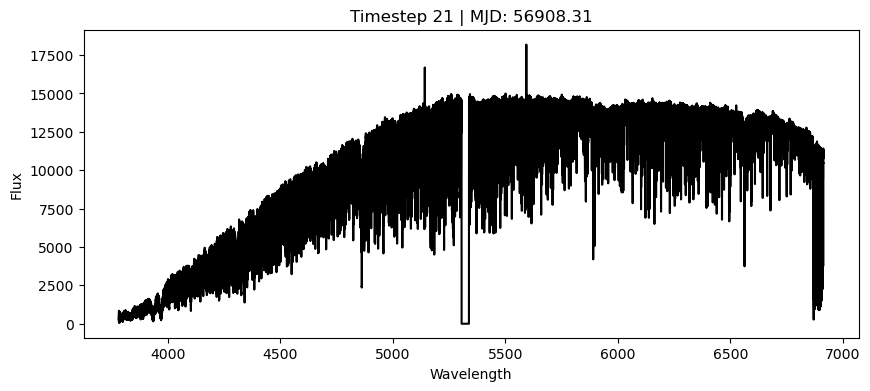

In [9]:
from matplotlib.animation import FuncAnimation

wavelengths = harps["wavelengths"][:]
fluxes = harps["fluxes"][:]
mjds = harps["mjds"][:]

fig, ax = plt.subplots(figsize=(10, 4))
line, = ax.plot(wavelengths[0], fluxes[0], color="black")
ax.set_xlabel("Wavelength")
ax.set_ylabel("Flux")
title = ax.set_title(f"Timestep 0 | MJD: {mjds[0]:.2f}")

def update(frame):
    line.set_xdata(wavelengths[frame])
    line.set_ydata(fluxes[frame])
    title.set_text(f"Timestep {frame} | MJD: {mjds[frame]:.2f}")
    return line, title

ani = FuncAnimation(
    fig, update, frames=range(fluxes.shape[0]), interval=300, blit=False, repeat=True
)

ani.save("harps_animation.gif", writer="ffmpeg")

plt.show()